# 02 — Unified Model Training: MLP, LSTM, Hybrid & Random Forest
Train and compare every integrated model family from one notebook using a
single registry, one split policy, and one centralized training API.

| Architecture | Description |
|---|---|
| **MLP** | Per-timestep features from the last step of the window |
| **LSTM** | Bi-directional LSTM over the full window |
| **Hybrid** | MLP branch (last step) + LSTM branch fused |
| **Random Forest** | Static tabular baseline trained on the same file-level splits |

This notebook is the canonical training entry point.
All model families share the same registry-driven train/val/test split,
which prevents file-level leakage and enables fair comparisons.

## 1. Imports & setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

from library.utils import setup_logging, get_device, get_num_workers
from library.config import BatchConfig
from library.data import prepare_file_registry, assign_splits
from library.data.registry import save_registry_manifest  # A1/A2: manifest persistence
from library.models import run_model_task

setup_logging()
%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## 2. Configuration
Tune this section before running training.

### Paths
- `DATA_DIR`: folder containing parquet simulations.
- `OUTPUT_DIR`: artifact destination (models, plots, scalers, reports).

### Sequence windowing
- `WINDOW_SIZE`: timesteps per sequence sample (larger captures longer dynamics, costs more RAM/time).
- `STRIDE`: spacing between windows (smaller = more overlap and more samples).

### Training controls
- `BATCH_SIZE`: sequence mini-batch size for neural models; lower if you hit memory limits.
- `EPOCHS`: maximum epochs.
- `PATIENCE`: early-stopping patience based on validation loss.

### Dataset scope
- `MAX_RUNS`: optional cap on number of simulation files for quicker experiments.
  Set to `None` for full training; keep this value fixed across experiments for fairness.

### Model selection
- `MODEL_MODES`: list of model backends to run.
- `CUSTOM_MODEL_RUNNERS`: plug-in runners for future custom modes.

### Leakage safety
Do not manually build your own split in downstream cells. Always use
`prepare_file_registry(...)` + `assign_splits(...)` once from this notebook so
all models evaluate on the same held-out files.

In [2]:
# -------- Paths --------
DATA_DIR = "dataset"
OUTPUT_DIR = "outputs/sequence_models"
MANIFEST_PATH = f"{OUTPUT_DIR}/registry_manifest.json"  # A1/A2: persisted registry + model paths
pathlib.Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# -------- Sequence/window parameters --------
# 2016 = 7 days at 5-minute cadence (7 * 24 * 12).
# Increase for longer temporal context; decrease to reduce memory/time.
WINDOW_SIZE = 576

# 288 = 1 day at 5-minute cadence.
# Smaller stride creates more overlapping windows and longer training time.
STRIDE = 288

# -------- Training hyperparameters --------
BATCH_SIZE = 128   # Lower this first if you see memory pressure.
EPOCHS = 30        # Max epochs; early stopping can end sooner.
PATIENCE = 7       # Stop after N non-improving validation epochs.

# -------- Data scope --------
# None = all runs. Use an int (e.g., 96) for fast/debug experiments.
# NOTE: this is intentionally only here in notebook 02 — notebook 03
# loads the registry from MANIFEST_PATH instead of re-deriving it, so
# it never re-runs prepare_file_registry() and this constant never
# affects eval (A1 split-leakage fix).
MAX_RUNS = None

# -------- Redundancy reduction (tabular family only) --------
# Thins whichever fault_active value is locally the MAJORITY within each
# *training* file (decided per file -- NOT assumed to be the healthy side;
# measured on this batch via 01_data_exploration.ipynb's "Fault Prevalence"
# chart: ~80% of rows are fault_active=True here, so faulted rows are what
# actually gets thinned). The minority-class rows are always kept in full,
# and the test split is never thinned (see load_split's docstring). No
# effect on mlp/lstm/hybrid, which need contiguous per-file timesteps for
# windowing.
#
# 1 = no thinning. Both RandomForestClassifier (class_weight="balanced") and
# the sequence models' weighted cross-entropy already compensate for class
# imbalance in the loss, so this isn't required for model quality -- it's a
# memory/speed lever. A factor of ~4 on an 80/20 split lands close to 1:1;
# pushing well past that starts manufacturing a new imbalance in the other
# direction rather than just trimming redundancy.
MAJORITY_THIN_FACTOR = 4

# -------- Tabular row caps --------
# "auto" only guarantees the LOADED DATA fits in memory -- it has no idea
# what you do with that data afterward. RandomForestClassifier(n_estimators=200,
# n_jobs=-1) does NOT scale gently: with "auto" resolving to ~23M rows here,
# fitting 200 trees in parallel across every CPU core was enough to get the
# whole kernel process OS-killed (no Python traceback -- that's the signature
# of an out-of-memory SIGKILL, not a raised exception) right as RF training
# started. RF also gets essentially no accuracy benefit from tens of millions
# of rows once class_weight="balanced" + stratified sampling already give it
# good class coverage, so this is a pure cost with no return.
#
# A concrete, conservative cap avoids this regardless of what "auto" would
# otherwise compute from available RAM. Start here; if training completes
# comfortably (watch system memory during the "RANDOM_FOREST" step), you can
# try raising it -- but scale up gradually and watch memory, rather than
# jumping back to "auto"/None, since neither knows about this failure mode.
MAX_TRAIN_ROWS = 1_000_000
MAX_TEST_ROWS  = 1_000_000

# -------- Batched tabular training --------
# A DIFFERENT fix from MAX_TRAIN_ROWS/"auto" above -- those only bound how
# much gets LOADED, not whether fitting a model on it fits in memory.
# RandomForestClassifier.fit() needs its whole training matrix at once no
# matter how it got capped, and with n_jobs parallelism this can still
# collapse the workstation (no Python traceback -- an OS-level OOM kill,
# not a raised exception) even at a modest, already-capped row count.
#
# Setting ROWS_PER_BATCH switches the tabular family to batched training:
# train_entries are grouped into FILES_PER_BATCH-file batches, each loaded
# and used to grow the forest via scikit-learn's warm_start one batch at a
# time -- previously-built trees are untouched, only NEW trees are fit on
# each new batch -- so peak memory is bounded by one batch's data, never
# the whole training set. The requested n_estimators (200 by default) is
# still the FINAL forest size; it's just split across batches automatically.
#
# None = batching disabled (single load + single .fit(), as before). Only
# affects the tabular family and only modes supporting warm_start
# (currently just "random_forest") -- mlp/lstm/hybrid already train in
# batches by construction (memmap-backed windows + DataLoader) and are
# untouched either way.
ROWS_PER_BATCH  = 200_000
FILES_PER_BATCH = 10

# -------- Unified model selection --------
# Tabular modes (estimator-agnostic): "random_forest", "gradient_boosting",
#   "logistic_regression", "ebm" (optional deps: lightgbm, interpret).
# Sequence modes: "mlp", "lstm", "hybrid".
# Unknown modes are skipped unless a custom runner is provided.
MODEL_MODES = ["mlp", "lstm", "hybrid", "random_forest"]

# Map custom mode name -> callable runner(task_name=..., target_col=..., ...)
CUSTOM_MODEL_RUNNERS = {}


In [3]:
# Load batch configuration and runtime environment details.
cfg = BatchConfig(DATA_DIR)
device = get_device()
n_workers = get_num_workers()

print(f"Device:  {device}")
print(f"Workers: {n_workers}")
print(cfg)


  Config: array=5.34 kWp, 9 location(s) from batch_config.json
  Simulation-only columns found in data and excluded from all feature sets: ['detailed_balance_efficiency_pct'] (theoretical-only), ['ac_wiring_loss_factor', 'aging_factor', 'aoi_correction_factor', 'availability_factor', 'bifacial_gain', 'dc_wiring_loss_factor', 'inverter_derating_factor', 'inverter_efficiency', 'inverter_loss_kw', 'lid_factor', 'mismatch_loss_factor', 'shading_factor', 'snow_loss_factor', 'soiling_factor', 'spectral_factor', 'vulnerability'] (simulator-internal — never a training input, even for "full")
  Columns: 11 SCADA, 6 IV-curve, 5 stress, 38 constant (excluded), 17 simulation-only (excluded), 0 uncategorized (excluded), 22 total features
Device: GPU — NVIDIA GeForce RTX 4090
Device:  cuda
Workers: 8
BatchConfig(array_kwp=5.34, locations=9, features=22)


## 3. Build file registry & assign splits

In [4]:
# No data is loaded here — just file paths and fault-type metadata
registry = prepare_file_registry(DATA_DIR, cfg, max_runs=MAX_RUNS)
assign_splits(registry)

fault_types = sorted({e['fault_type'] for e in registry})
print(f"\nFault types in registry: {fault_types}")


Registry: 418 files, 12 fault types
  train: 260 files
  val: 79 files
  test: 79 files

Fault types in registry: ['bypass_diode_short', 'cell_crack', 'combo', 'connector_burnout', 'curtailment', 'mppt_failure', 'none', 'pid', 'sensor_drift', 'solder_fatigue', 'string_failure', 'sudden_soiling']


## 4. Feature list

In [5]:
# Use the centralized feature set shared across all model families.
feature_list = cfg.feature_set("full")
print(f"Total features: {len(feature_list)}")


Total features: 30


## 5. Task A — Fault Detection

In [6]:
detection_details = run_model_task(
    task_name="Fault Detection",
    target_col="fault_active",
    registry=registry,
    feature_cols=feature_list,
    model_modes=MODEL_MODES,
    output_dir=OUTPUT_DIR,
    cfg=cfg,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    device=device,
    patience=PATIENCE,
    num_workers=n_workers,
    max_train_rows=MAX_TRAIN_ROWS,
    max_test_rows=MAX_TEST_ROWS,
    majority_thin_factor=MAJORITY_THIN_FACTOR,
    rows_per_batch=ROWS_PER_BATCH,
    files_per_batch=FILES_PER_BATCH,
    custom_runners=CUSTOM_MODEL_RUNNERS,
    return_details=True,  # A2: need model_path per mode for the manifest
)
detection_reports = {m: d["report"] for m, d in detection_details.items()}
print("Trained detection modes:", ", ".join(detection_reports))



  TABULAR FAULT DETECTION  —  modes: random_forest
  Loading test  files …
After daytime filter: 307,611 rows
After daytime filter: 308,092 rows
After daytime filter: 307,730 rows
After daytime filter: 306,893 rows
After daytime filter: 307,731 rows
After daytime filter: 307,362 rows
After daytime filter: 304,076 rows
After daytime filter: 306,872 rows
After daytime filter: 306,362 rows
After daytime filter: 303,910 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 10/79 entries
After daytime filter: 305,312 rows
After daytime filter: 306,643 rows
After daytime filter: 306,438 rows
After daytime filter: 302,403 rows
After daytime filter: 306,472 rows
After daytime filter: 305,936 rows
After daytime filter: 306,525 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 17/79 entries
After daytime filter: 306,950 rows
After daytime filter: 298,935 rows
After daytime f


MLP training curves:


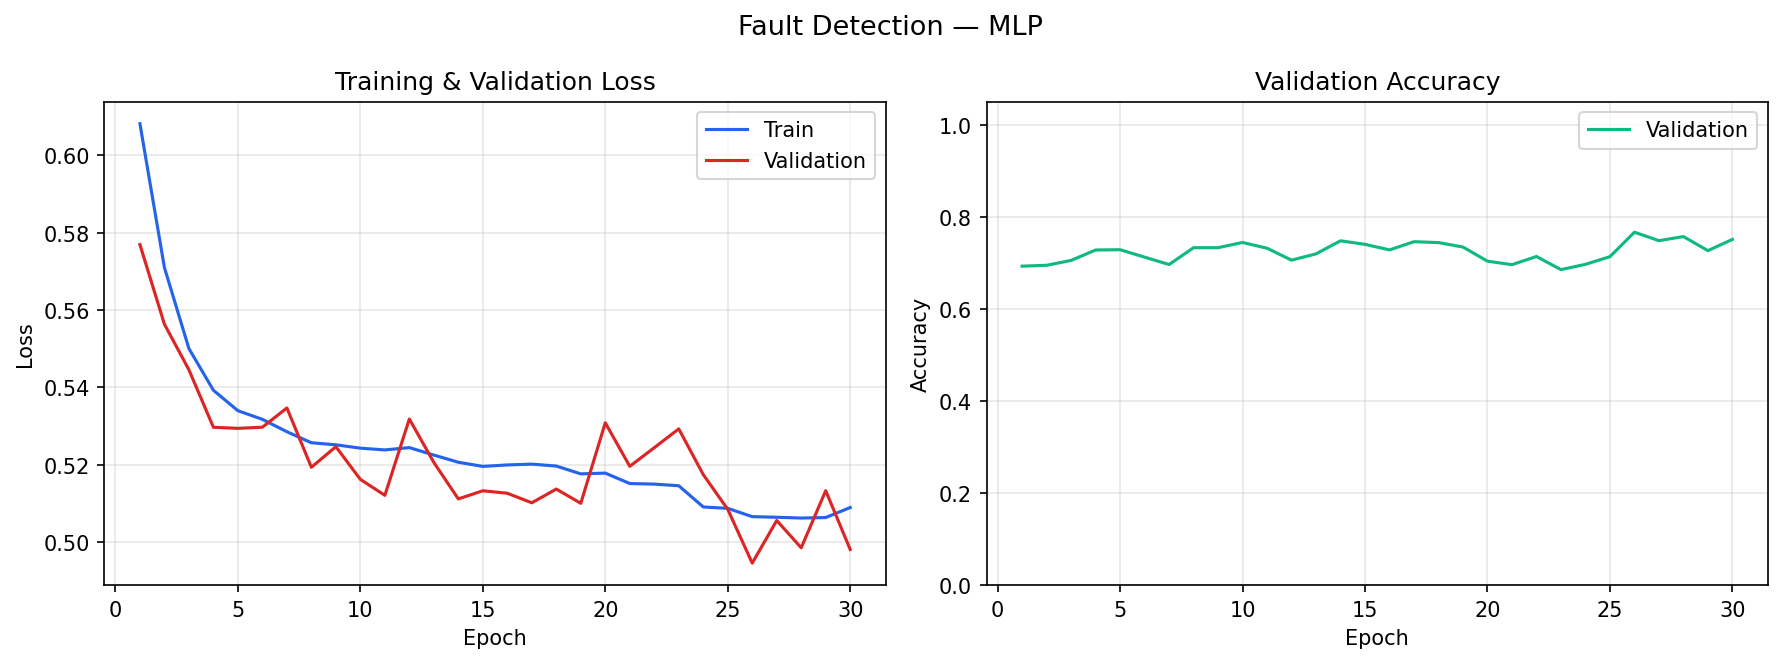


LSTM training curves:


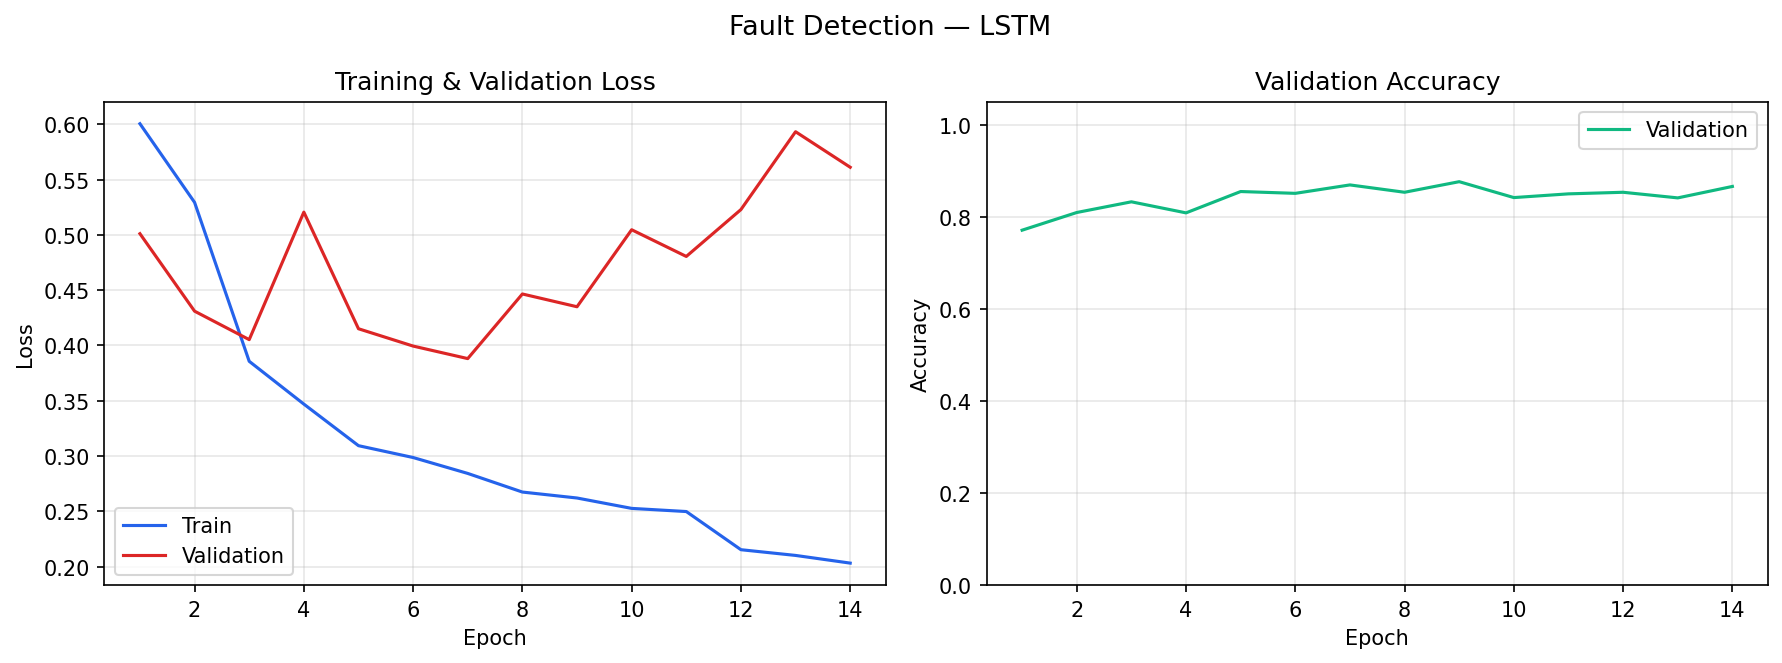


HYBRID training curves:


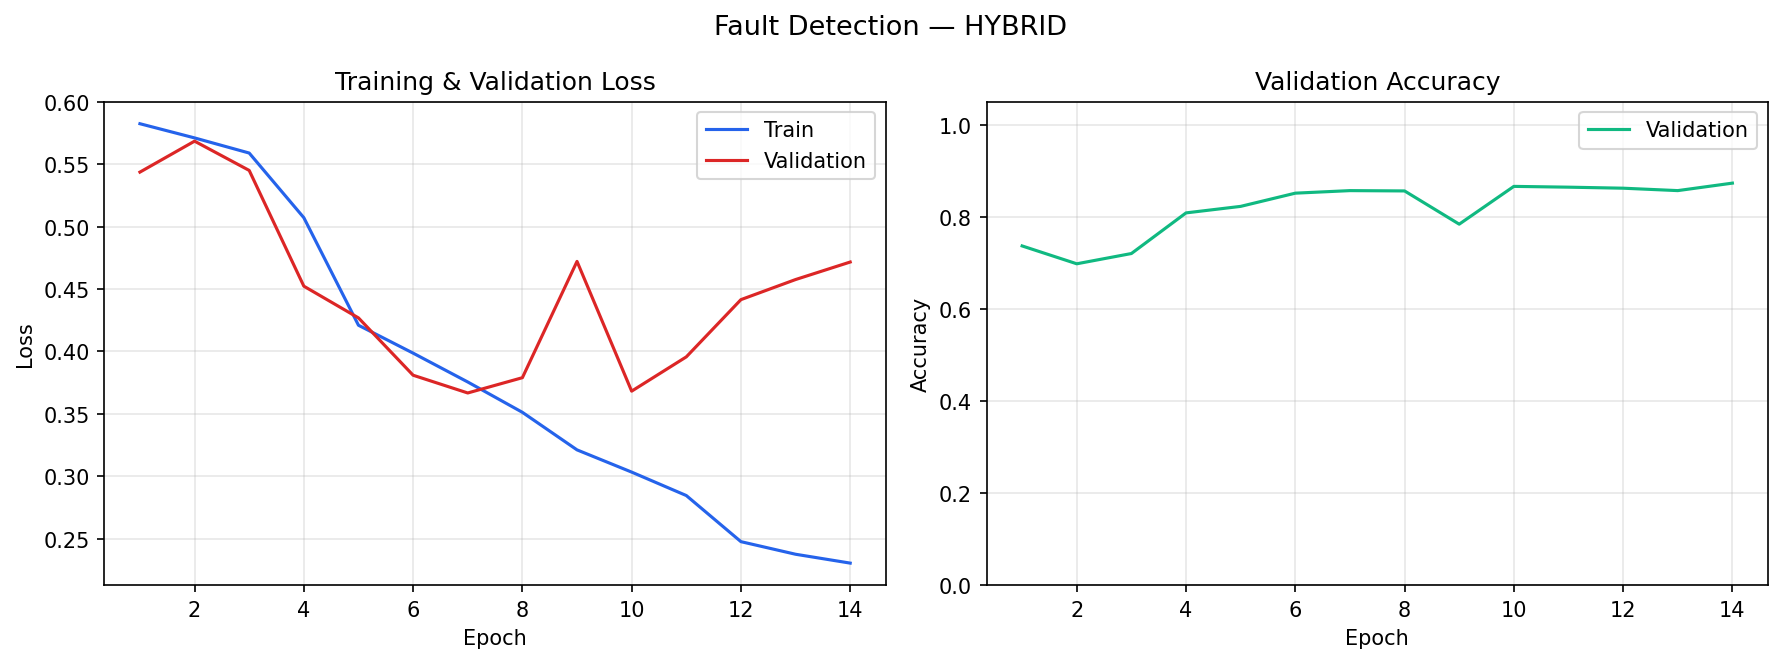

In [7]:
from IPython.display import Image, display as ipy_display

for mode in detection_reports:
    p = f"{OUTPUT_DIR}/curves_fault_detection_{mode}.png"
    if pathlib.Path(p).exists():
        print(f"\n{mode.upper()} training curves:")
        ipy_display(Image(p))


## 6. Task B — Fault Classification (multi-class)

In [8]:
classification_details = run_model_task(
    task_name="Fault Classification",
    target_col="fault_type",
    registry=registry,
    feature_cols=feature_list,
    model_modes=MODEL_MODES,
    output_dir=OUTPUT_DIR,
    cfg=cfg,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    device=device,
    patience=PATIENCE,
    num_workers=n_workers,
    max_train_rows=MAX_TRAIN_ROWS,
    max_test_rows=MAX_TEST_ROWS,
    majority_thin_factor=MAJORITY_THIN_FACTOR,
    rows_per_batch=ROWS_PER_BATCH,
    files_per_batch=FILES_PER_BATCH,
    custom_runners=CUSTOM_MODEL_RUNNERS,
    return_details=True,  # A2: need model_path per mode for the manifest
)
classification_reports = {m: d["report"] for m, d in classification_details.items()}
print("Trained classification modes:", ", ".join(classification_reports))


  Shared label encoder: 6 classes — [np.str_('bypass_diode_short'), np.str_('cell_crack'), np.str_('combo'), np.str_('pid'), np.str_('sensor_drift'), np.str_('solder_fatigue')]

  TABULAR FAULT CLASSIFICATION  —  modes: random_forest
  Loading test  files …
After daytime filter: 306,843 rows
After daytime filter: 306,472 rows
After daytime filter: 308,122 rows
After daytime filter: 306,861 rows
After daytime filter: 306,643 rows
After daytime filter: 306,790 rows
After daytime filter: 304,181 rows
After daytime filter: 302,527 rows
After daytime filter: 304,167 rows
After daytime filter: 306,812 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 10/74 entries
After daytime filter: 306,872 rows
After daytime filter: 302,410 rows
After daytime filter: 304,147 rows
After daytime filter: 305,266 rows
After daytime filter: 304,076 rows
After daytime filter: 307,194 rows
After daytime filter: 306,683 rows
  Stratified subsample (b

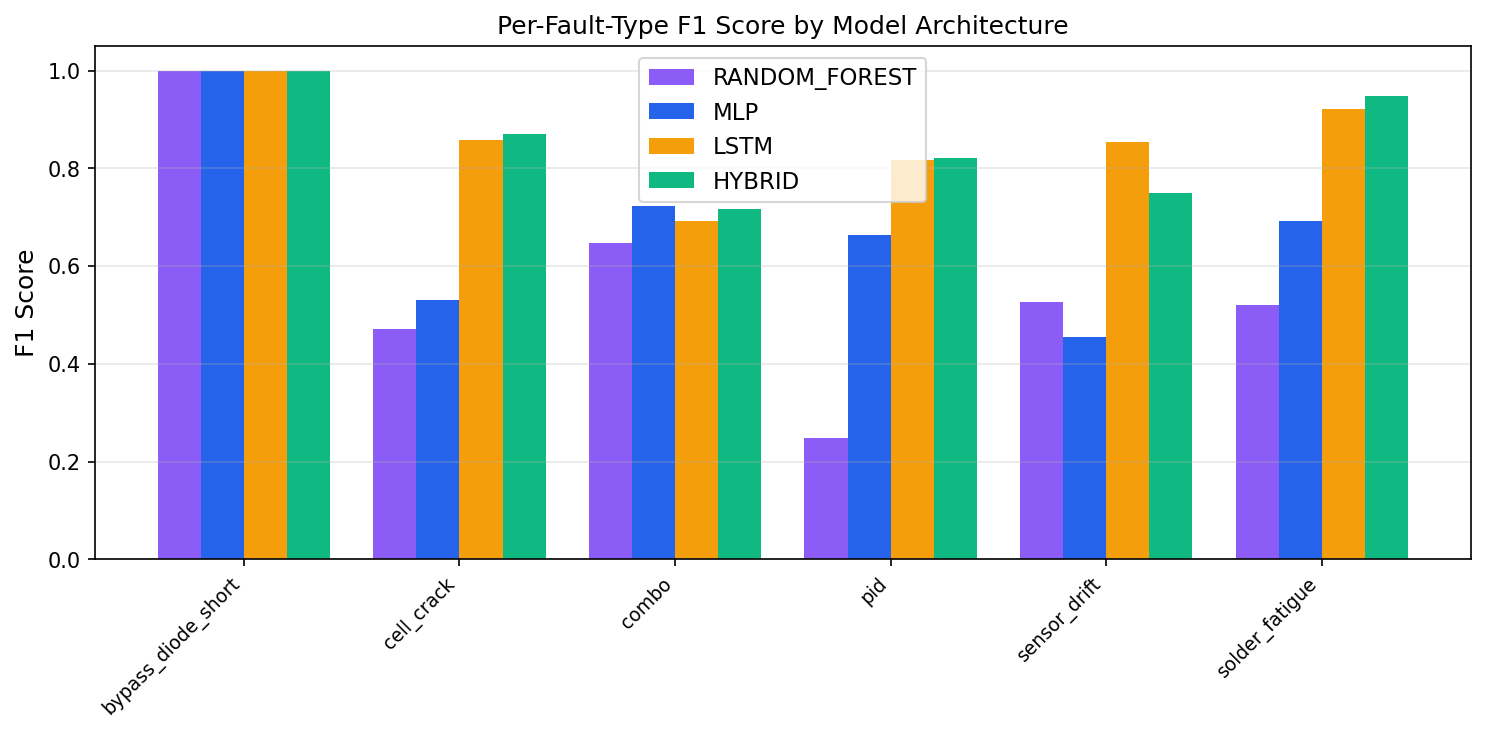

In [9]:
# Per-fault F1 comparison
p = f"{OUTPUT_DIR}/per_fault_f1_fault_classification.png"
if pathlib.Path(p).exists():
    ipy_display(Image(p))


## 7. Confusion matrices


fault_detection — HYBRID


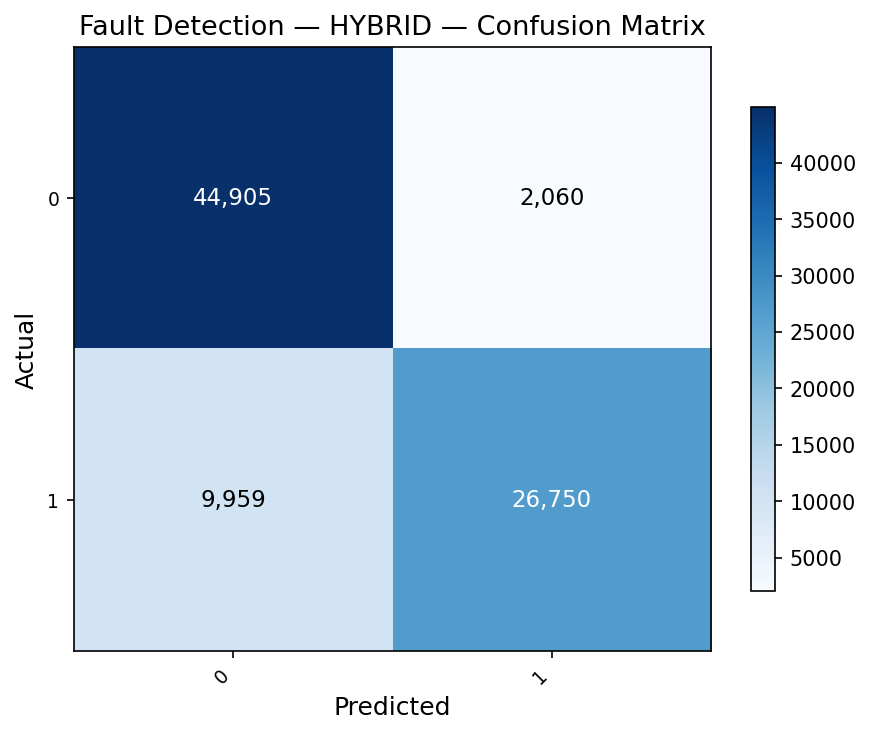


fault_detection — LSTM


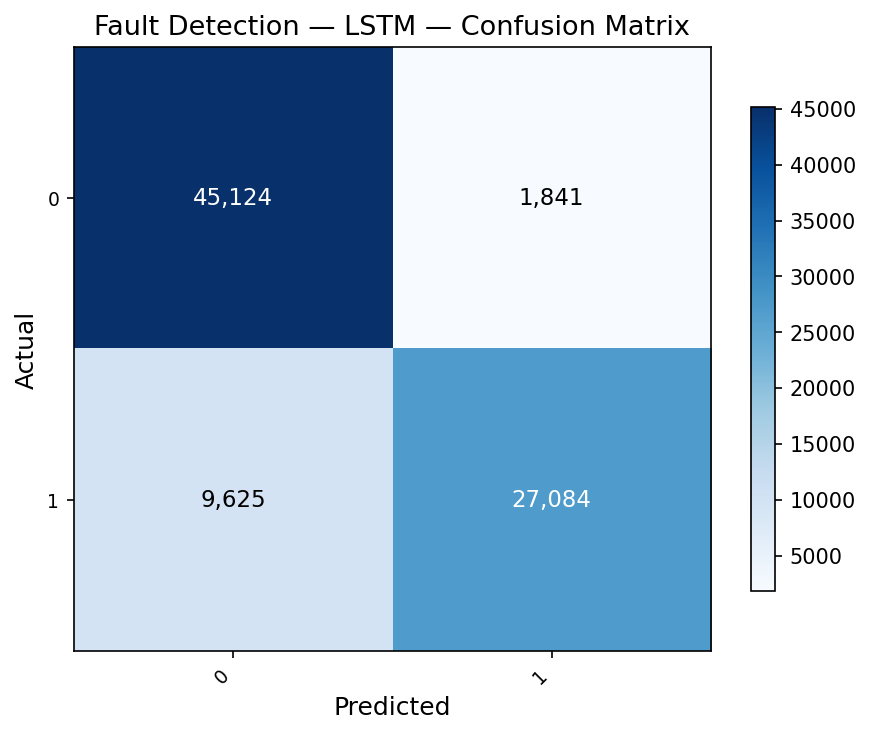


fault_detection — MLP


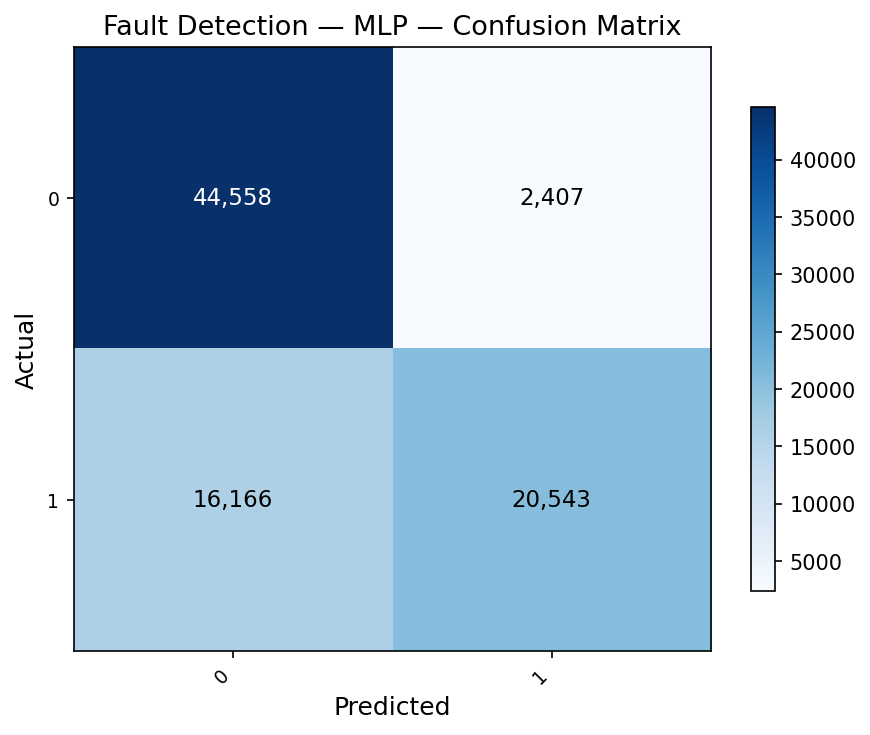


fault_detection — RANDOM_FOREST


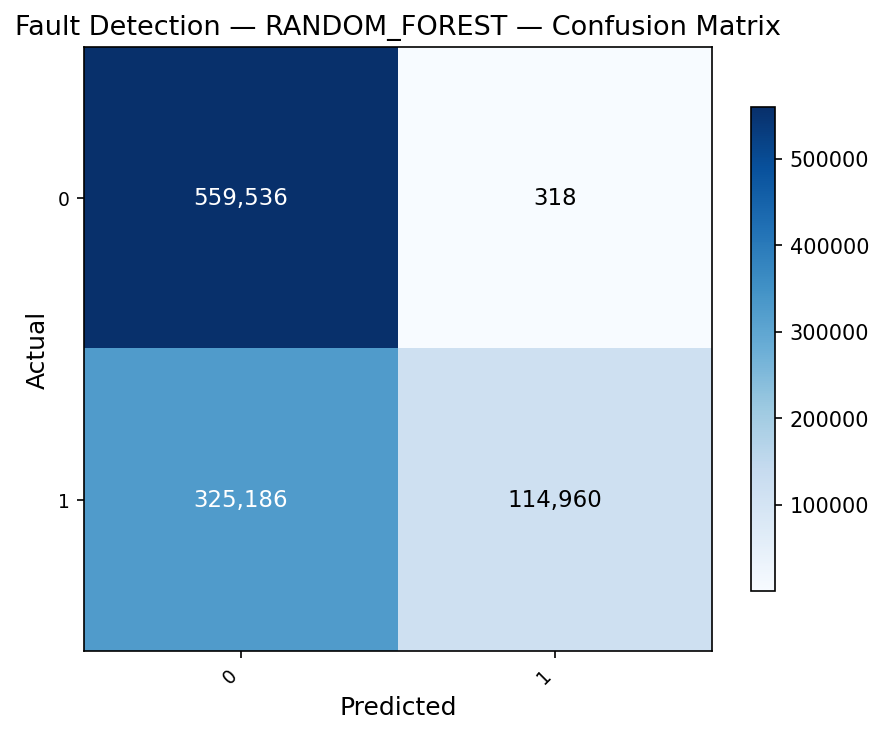


fault_classification — HYBRID


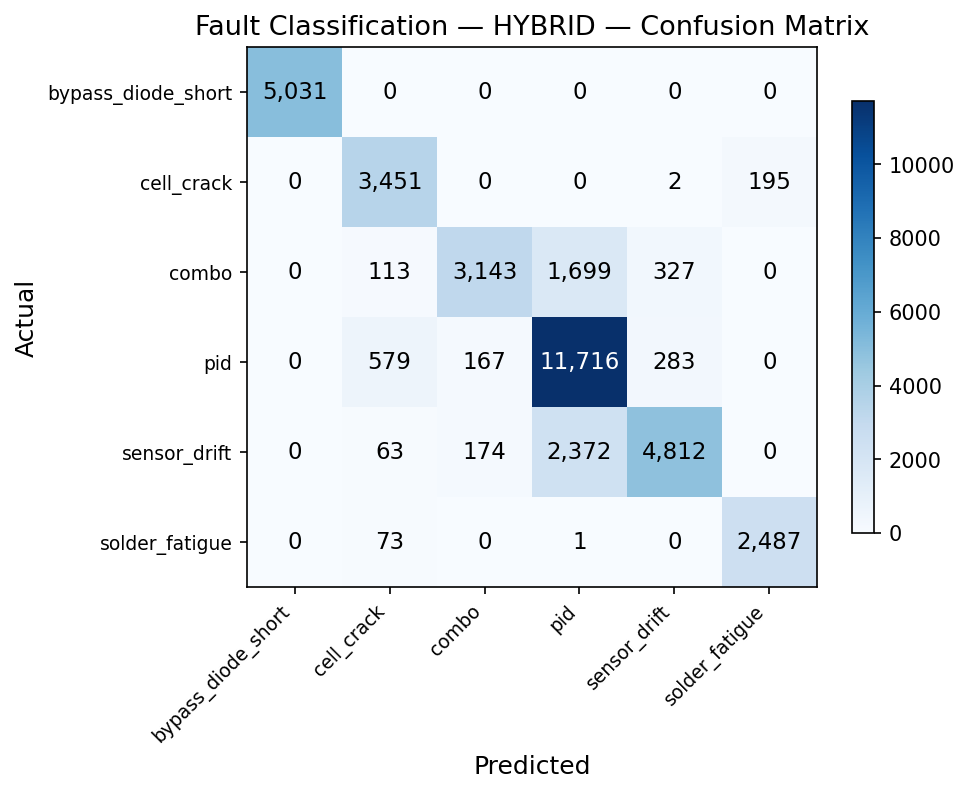


fault_classification — LSTM


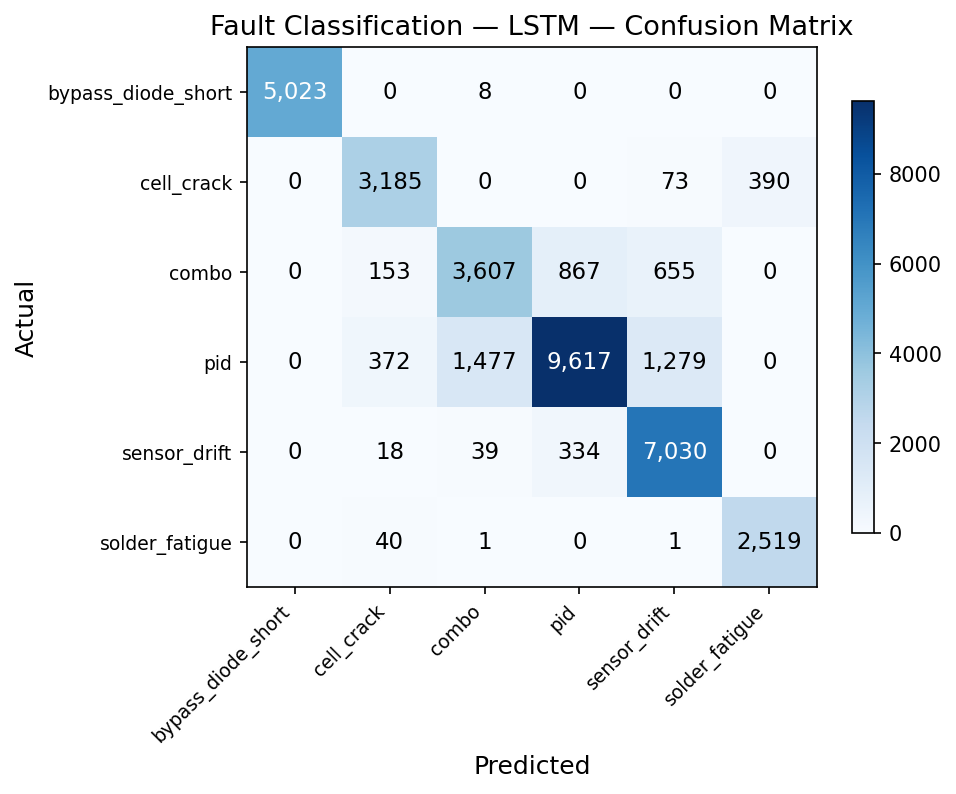


fault_classification — MLP


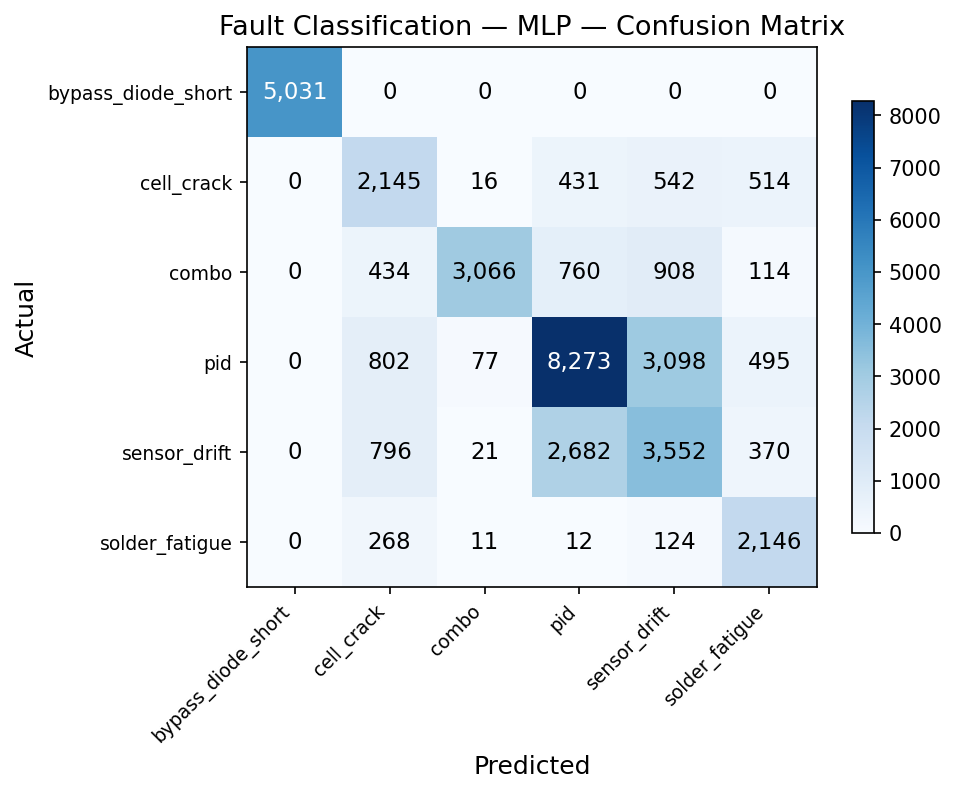


fault_classification — RANDOM_FOREST


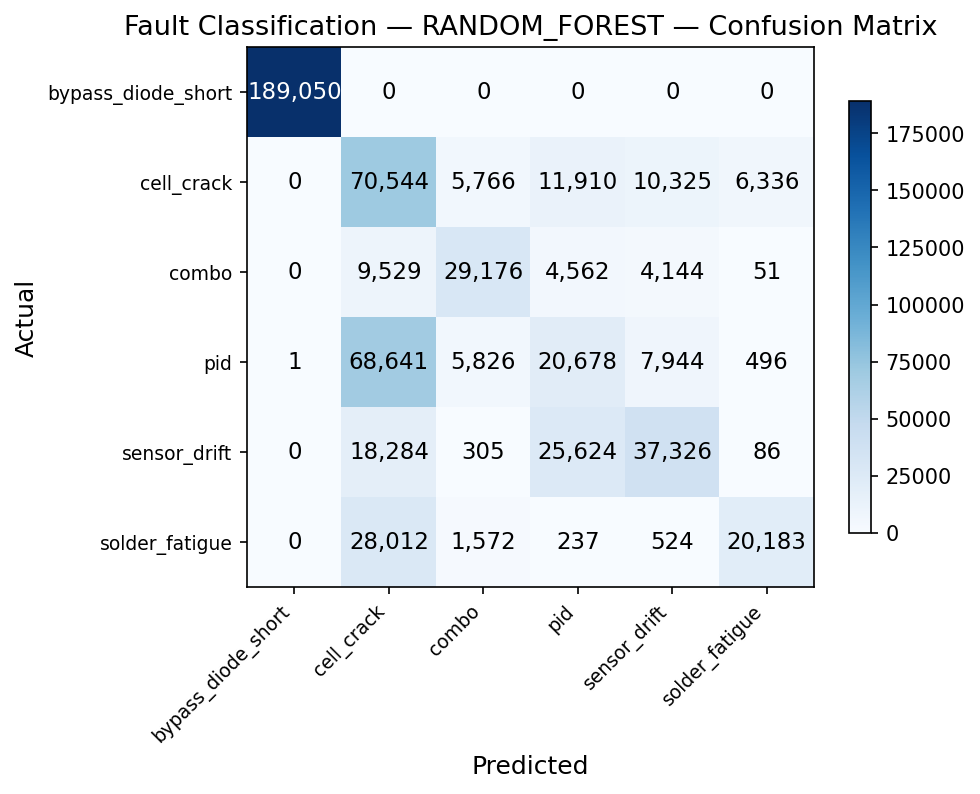


fault_detection — RANDOM_FOREST feature importance


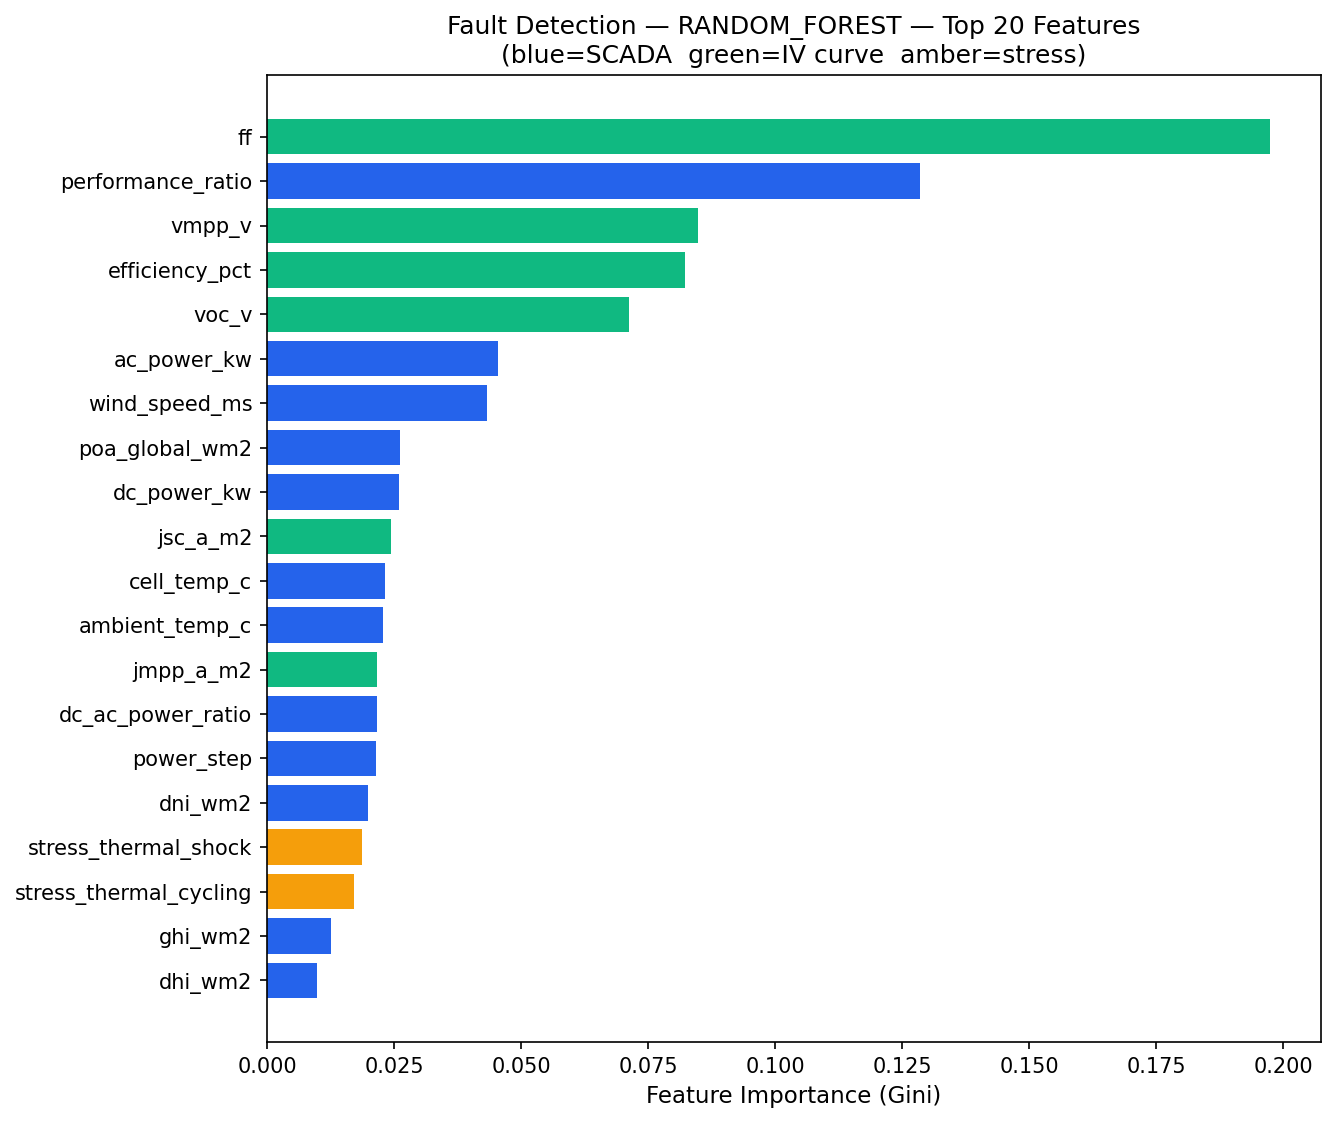


fault_classification — RANDOM_FOREST feature importance


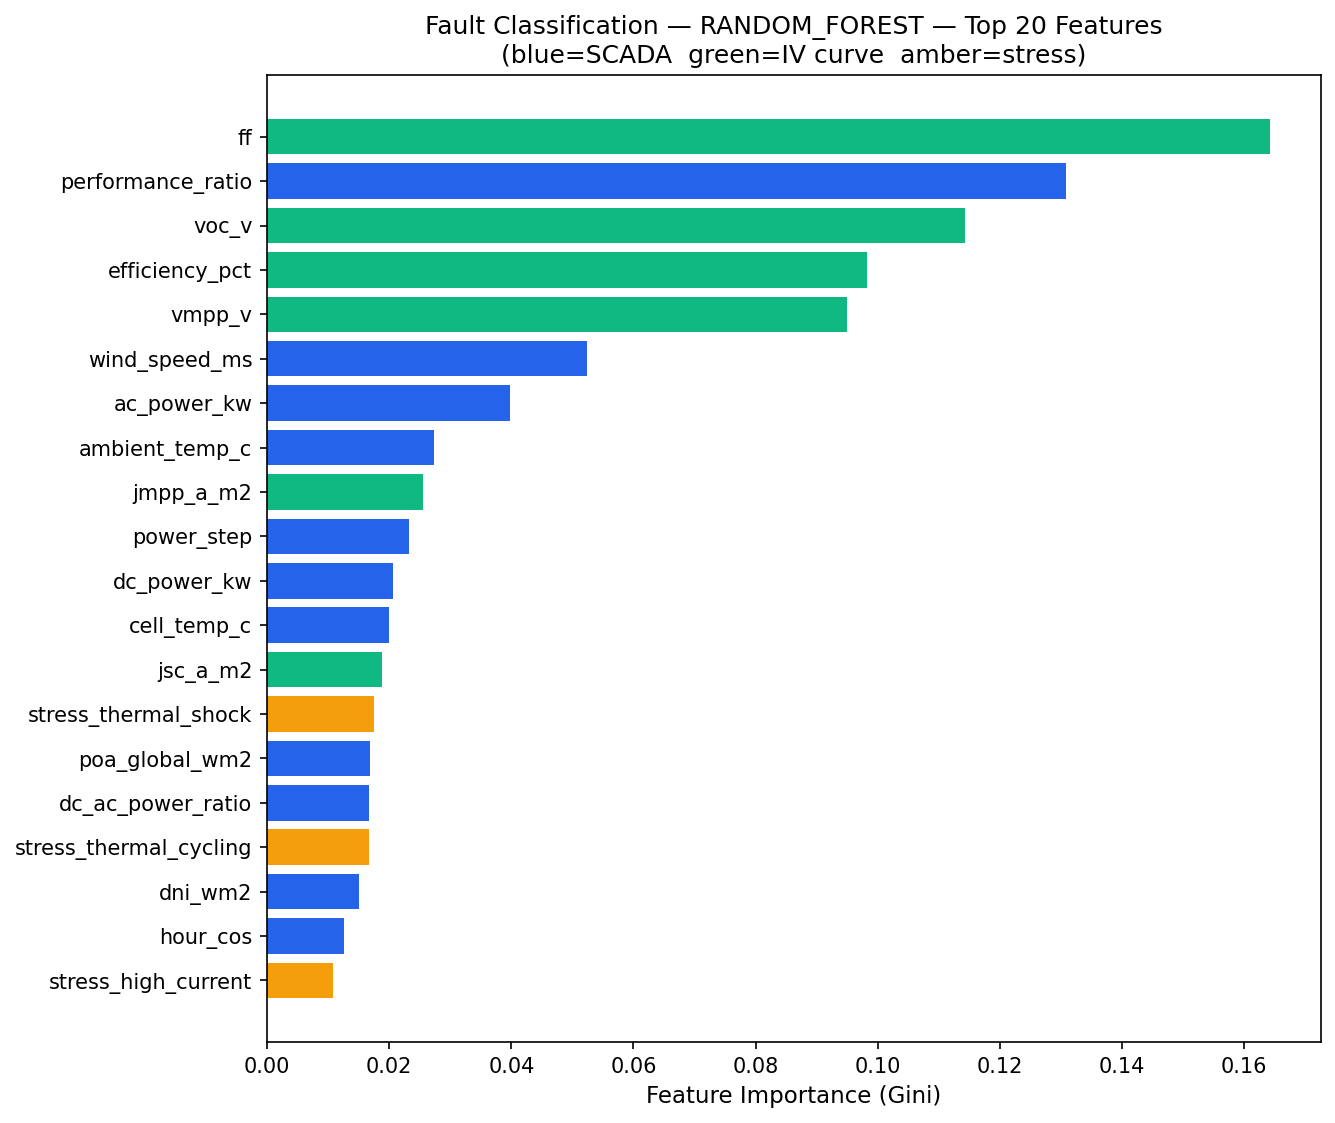

In [10]:
available_modes = sorted(set(detection_reports) | set(classification_reports))
for task_tag in ["fault_detection", "fault_classification"]:
    for mode in available_modes:
        p = f"{OUTPUT_DIR}/confusion_{task_tag}_{mode}.png"
        if pathlib.Path(p).exists():
            print(f"\n{task_tag} — {mode.upper()}")
            ipy_display(Image(p))

# Importance plots: show all modes that produced one (tree-based and coef_-based)
for task_tag in ["fault_detection", "fault_classification"]:
    for mode in available_modes:
        p = f"{OUTPUT_DIR}/importance_{task_tag}_{mode}.png"
        if pathlib.Path(p).exists():
            print(f"\n{task_tag} — {mode.upper()} feature importance")
            ipy_display(Image(p))


## 8. Advanced evaluations

In [11]:
from library.evaluation import run_temporal_split

temporal_results = run_temporal_split(
    registry,
    feature_list,
    pathlib.Path(OUTPUT_DIR),
    cfg,
    model_modes=MODEL_MODES,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    device=device,
    patience=PATIENCE,
    num_workers=n_workers,
    max_train_rows=MAX_TRAIN_ROWS,
    max_test_rows=MAX_TEST_ROWS,
    majority_thin_factor=MAJORITY_THIN_FACTOR,
    rows_per_batch=ROWS_PER_BATCH,
    files_per_batch=FILES_PER_BATCH,
    custom_runners=CUSTOM_MODEL_RUNNERS,
)
if temporal_results:
    display(pd.DataFrame(temporal_results).T)



  TEMPORAL SPLIT (all model modes)
  Discovering sim_year range per file …
  sim_years found across all files: [1, 2, 3, 4, 5, 6]
  Train years: [1, 2, 3, 4, 5]  |  Test year: 6
  train: 215 files
  val: 62 files
  test: 62 files
  train_entries=215  val_entries=62  test_entries=339

  TABULAR FAULT DETECTION  —  modes: random_forest
  Loading test  files …
After daytime filter: 50,907 rows
After daytime filter: 50,928 rows
After daytime filter: 50,961 rows
After daytime filter: 50,917 rows
After daytime filter: 51,076 rows
After daytime filter: 50,813 rows
After daytime filter: 50,874 rows
After daytime filter: 50,905 rows
After daytime filter: 50,922 rows
After daytime filter: 50,866 rows
After daytime filter: 51,039 rows
After daytime filter: 50,794 rows
After daytime filter: 49,770 rows
After daytime filter: 51,127 rows
After daytime filter: 50,998 rows
After daytime filter: 50,404 rows
After daytime filter: 51,039 rows
After daytime filter: 50,887 rows
After daytime filter: 49,85

,detection_auc,classification_auc
random_forest,0.763207,0.882661
mlp,0.909104,0.958270
lstm,0.624715,0.996592
hybrid,0.954202,0.991589


## 9. Cross-location generalization

  train: 152 files
  val: 42 files
  test: 42 files

  TABULAR FAULT DETECTION  —  modes: random_forest
  Loading test  files …
After daytime filter: 306,825 rows
After daytime filter: 306,785 rows
After daytime filter: 306,887 rows
After daytime filter: 306,829 rows
After daytime filter: 306,868 rows
After daytime filter: 306,921 rows
After daytime filter: 306,715 rows
After daytime filter: 306,721 rows
After daytime filter: 306,801 rows
After daytime filter: 306,529 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 10/103 entries
After daytime filter: 306,435 rows
After daytime filter: 306,645 rows
After daytime filter: 306,782 rows
After daytime filter: 306,678 rows
After daytime filter: 306,845 rows
After daytime filter: 306,638 rows
After daytime filter: 306,746 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 17/103 entries
After daytime filter: 306,608 r

,model_mode,test_location,test_loc_id,detection_auc,classification_auc
0,random_forest,Miami,25.77_-80.19,0.724186,0.623122
1,mlp,Miami,25.77_-80.19,0.755262,0.781998
2,lstm,Miami,25.77_-80.19,0.814770,0.915542
3,hybrid,Miami,25.77_-80.19,0.897629,0.958149
4,random_forest,Houston,29.76_-95.37,0.776630,0.859886
5,mlp,Houston,29.76_-95.37,0.847789,0.891681
6,lstm,Houston,29.76_-95.37,0.913348,0.961582
7,hybrid,Houston,29.76_-95.37,0.918840,0.961499
8,random_forest,Phoenix,33.45_-112.07,0.809251,0.775542
9,mlp,Phoenix,33.45_-112.07,0.822885,0.944112



Cross-location summary — HYBRID


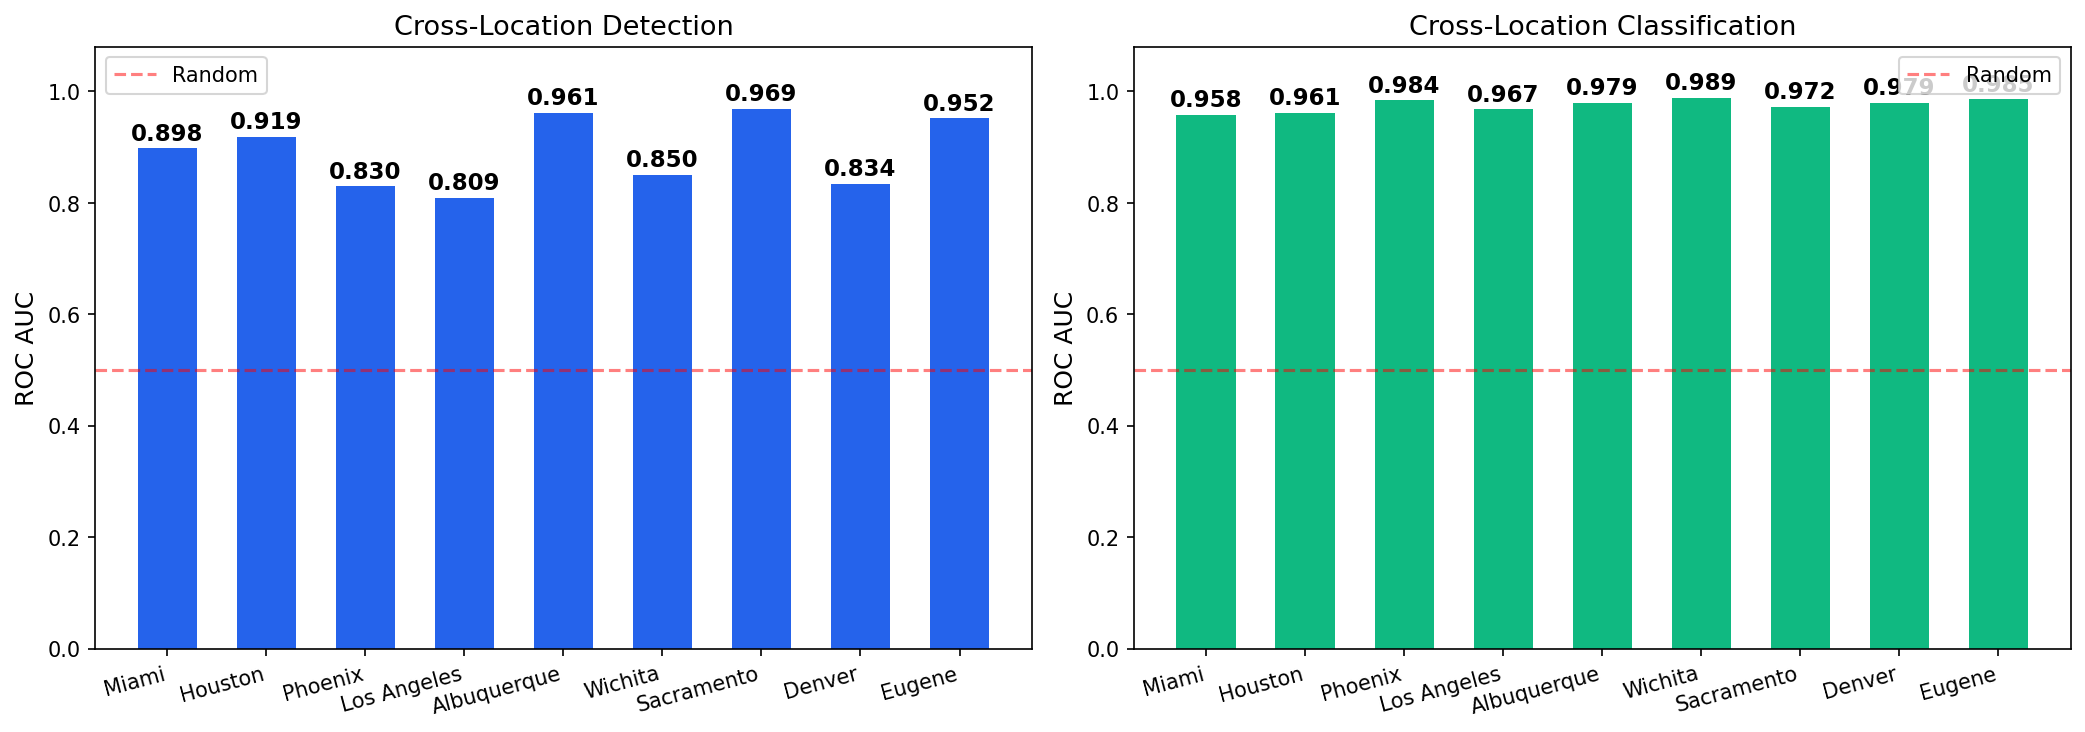


Cross-location summary — LSTM


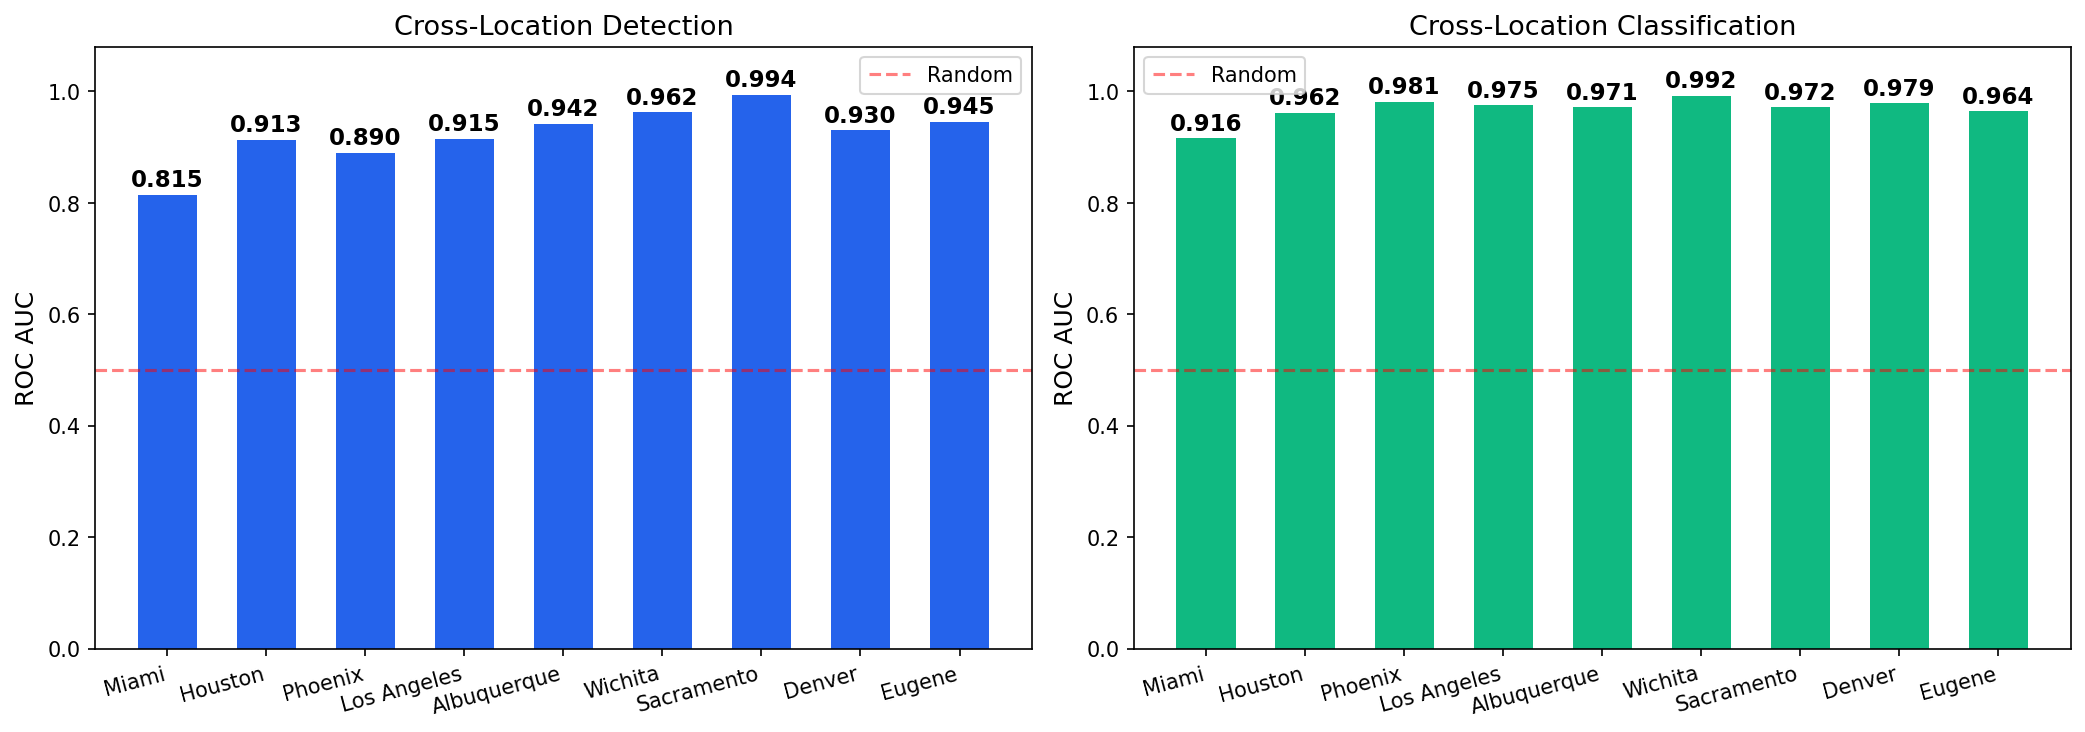


Cross-location summary — MLP


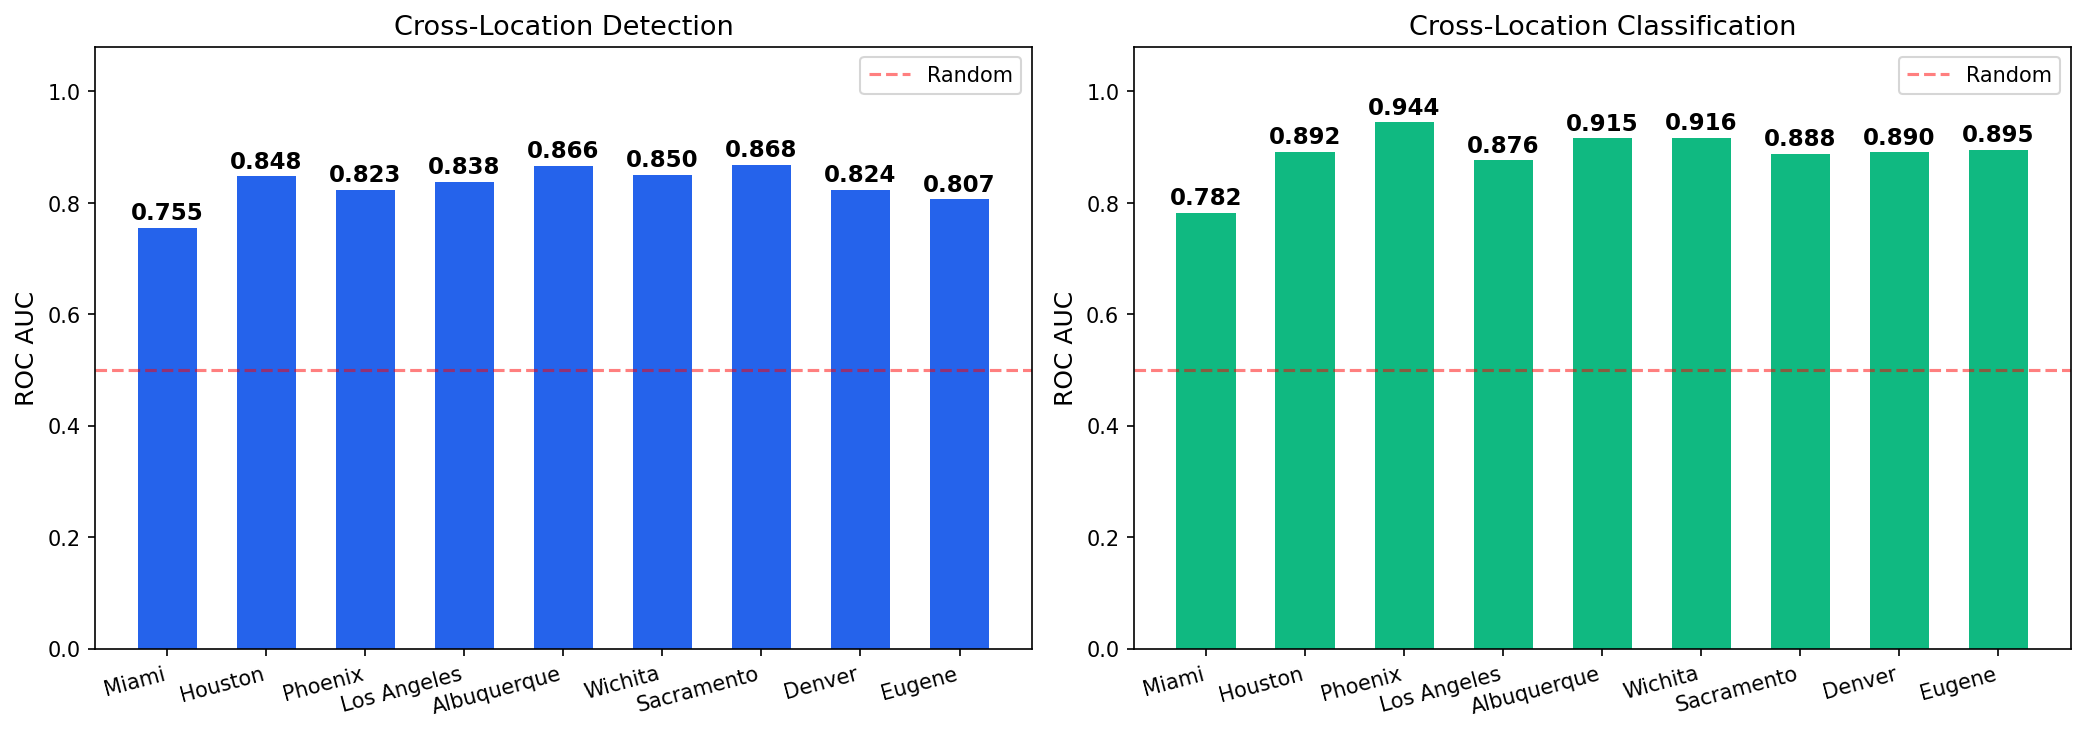


Cross-location summary — RANDOM_FOREST


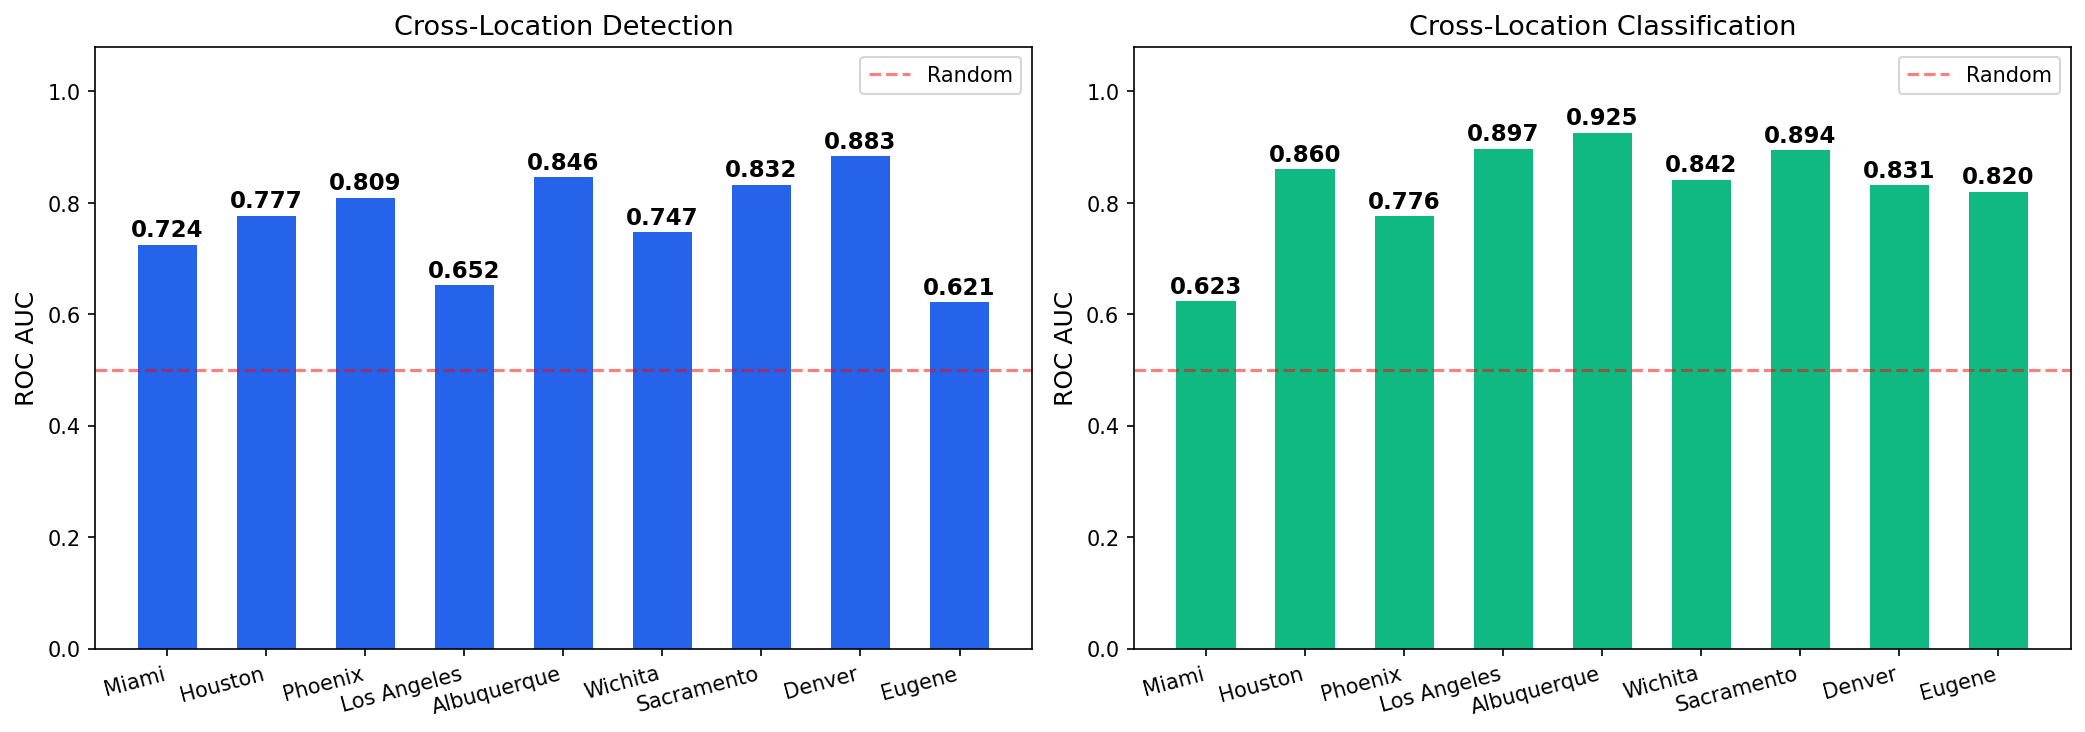

In [12]:
from library.evaluation import run_cross_location

cross_location_results = run_cross_location(
    registry,
    feature_list,
    pathlib.Path(OUTPUT_DIR),
    cfg,
    model_modes=MODEL_MODES,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    device=device,
    patience=PATIENCE,
    num_workers=n_workers,
    max_train_rows=MAX_TRAIN_ROWS,
    max_test_rows=MAX_TEST_ROWS,
    majority_thin_factor=MAJORITY_THIN_FACTOR,
    rows_per_batch=ROWS_PER_BATCH,
    files_per_batch=FILES_PER_BATCH,
    custom_runners=CUSTOM_MODEL_RUNNERS,
)
if cross_location_results:
    display(pd.DataFrame(cross_location_results))
    for mode in sorted({row["model_mode"] for row in cross_location_results}):
        p = pathlib.Path(OUTPUT_DIR) / f"cross_location_{mode}.png"
        if p.exists():
            print(f"\nCross-location summary — {mode.upper()}")
            ipy_display(Image(str(p)))


## 10. Feature ablation


  TABULAR FAULT DETECTION  —  modes: random_forest
  Loading test  files …
After daytime filter: 307,611 rows
After daytime filter: 308,092 rows
After daytime filter: 307,730 rows
After daytime filter: 306,893 rows
After daytime filter: 307,731 rows
After daytime filter: 307,362 rows
After daytime filter: 304,076 rows
After daytime filter: 306,872 rows
After daytime filter: 306,362 rows
After daytime filter: 303,910 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 10/79 entries
After daytime filter: 305,312 rows
After daytime filter: 306,643 rows
After daytime filter: 306,438 rows
After daytime filter: 302,403 rows
After daytime filter: 306,472 rows
After daytime filter: 305,936 rows
After daytime filter: 306,525 rows
  Stratified subsample (by fault_type) → 1,000,000 rows
  load_split: shrank buffer to 1,000,000 rows after 17/79 entries
After daytime filter: 306,950 rows
After daytime filter: 298,935 rows
After daytime f

,model_mode,feature_set,n_features,auc
0,random_forest,SCADA only,19,0.588219
1,mlp,SCADA only,19,0.664940
2,lstm,SCADA only,19,0.705205
3,hybrid,SCADA only,19,0.661043
4,random_forest,SCADA + stress,24,0.574177
5,mlp,SCADA + stress,24,0.649504
6,lstm,SCADA + stress,24,0.675951
7,hybrid,SCADA + stress,24,0.649340
8,random_forest,SCADA + IV curve,25,0.732878
9,mlp,SCADA + IV curve,25,0.821814



Feature ablation — HYBRID


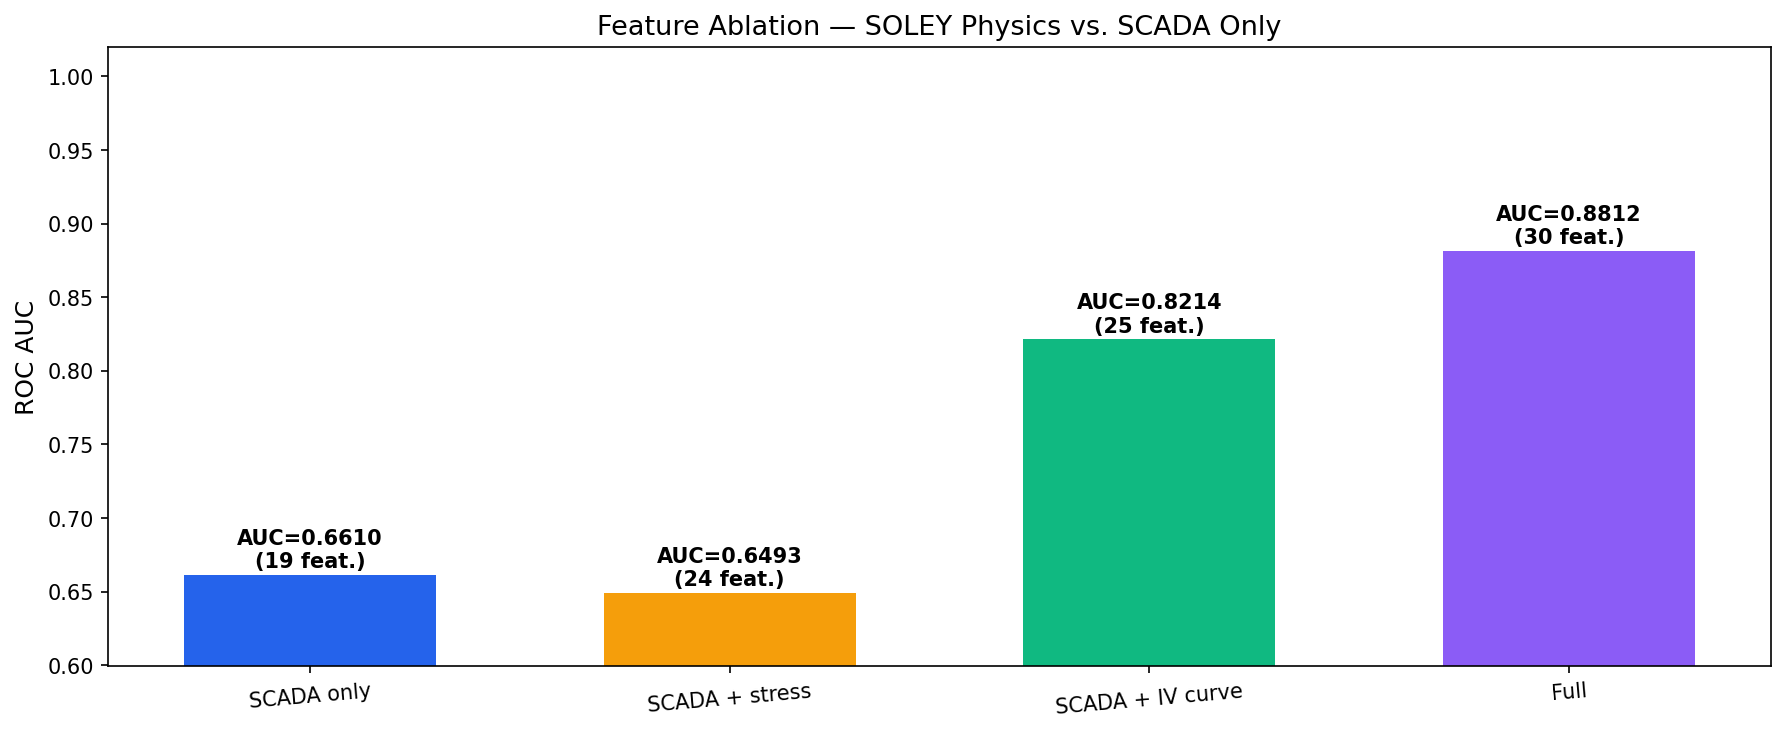


Feature ablation — LSTM


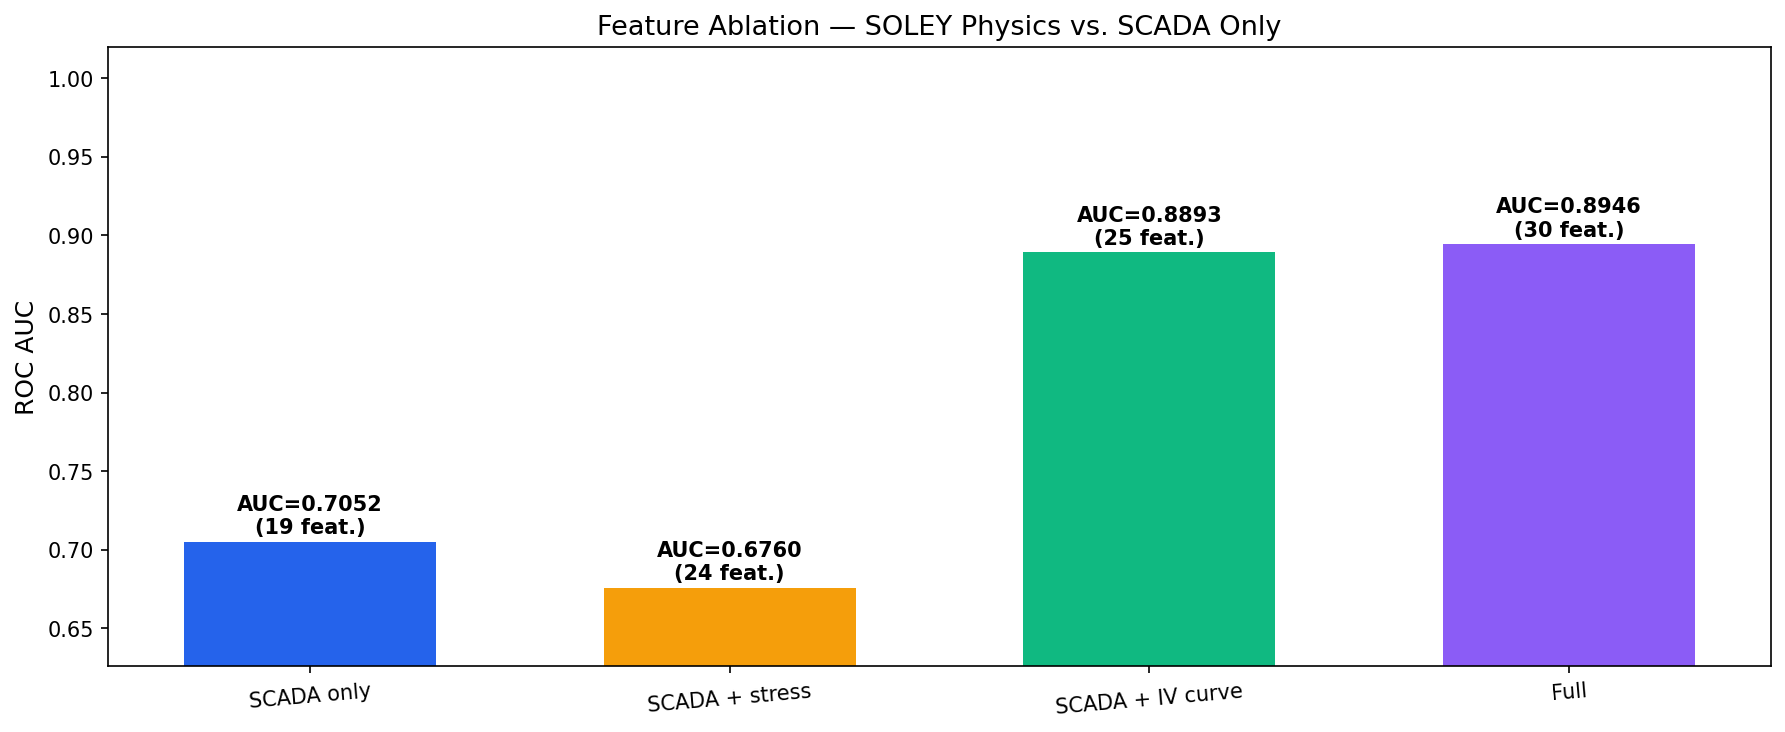


Feature ablation — MLP


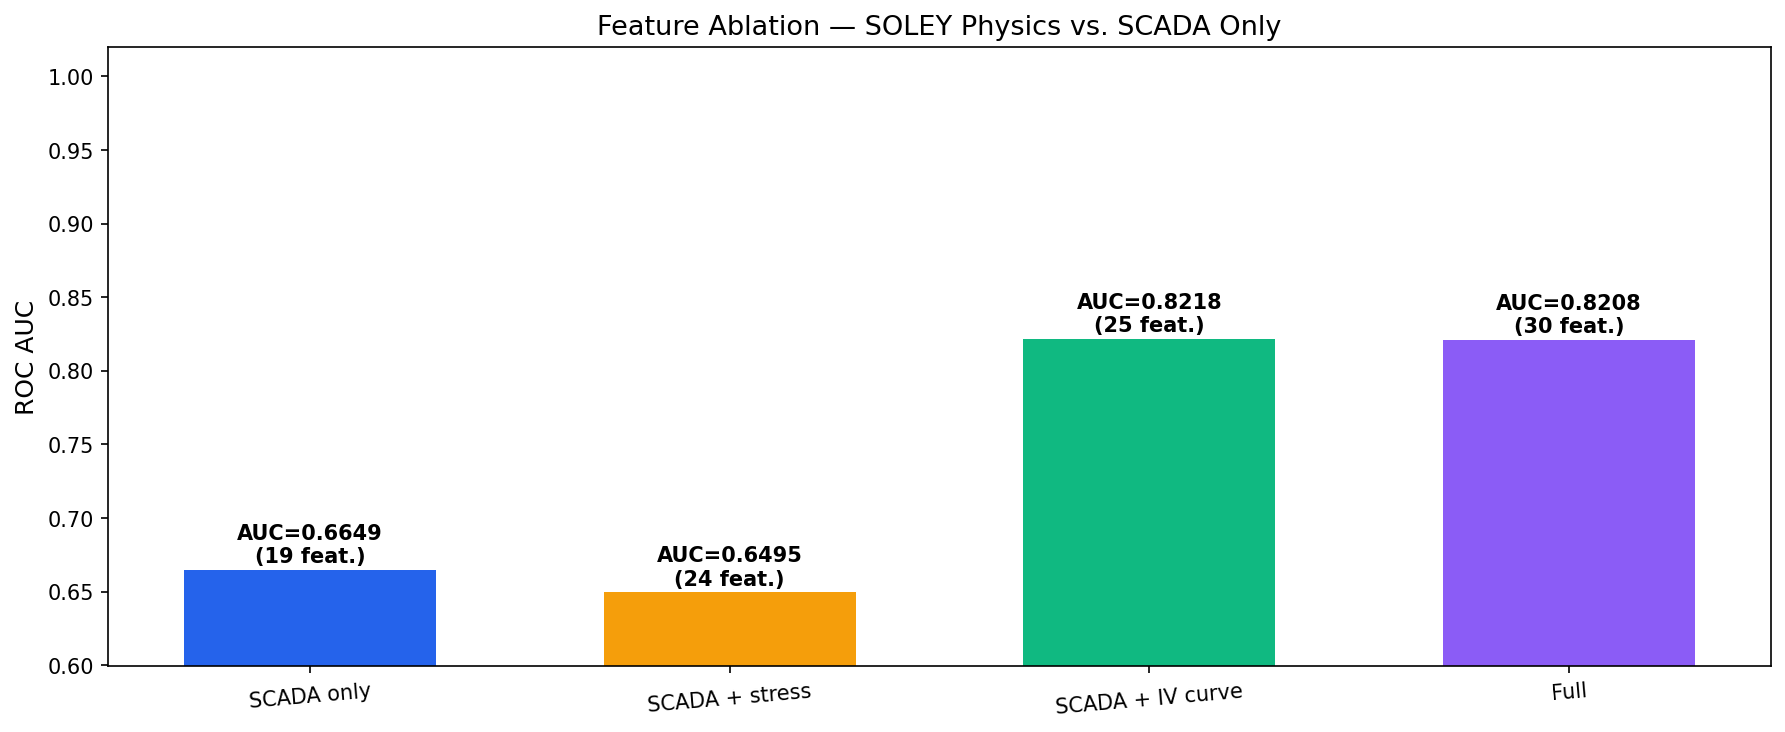


Feature ablation — RANDOM_FOREST


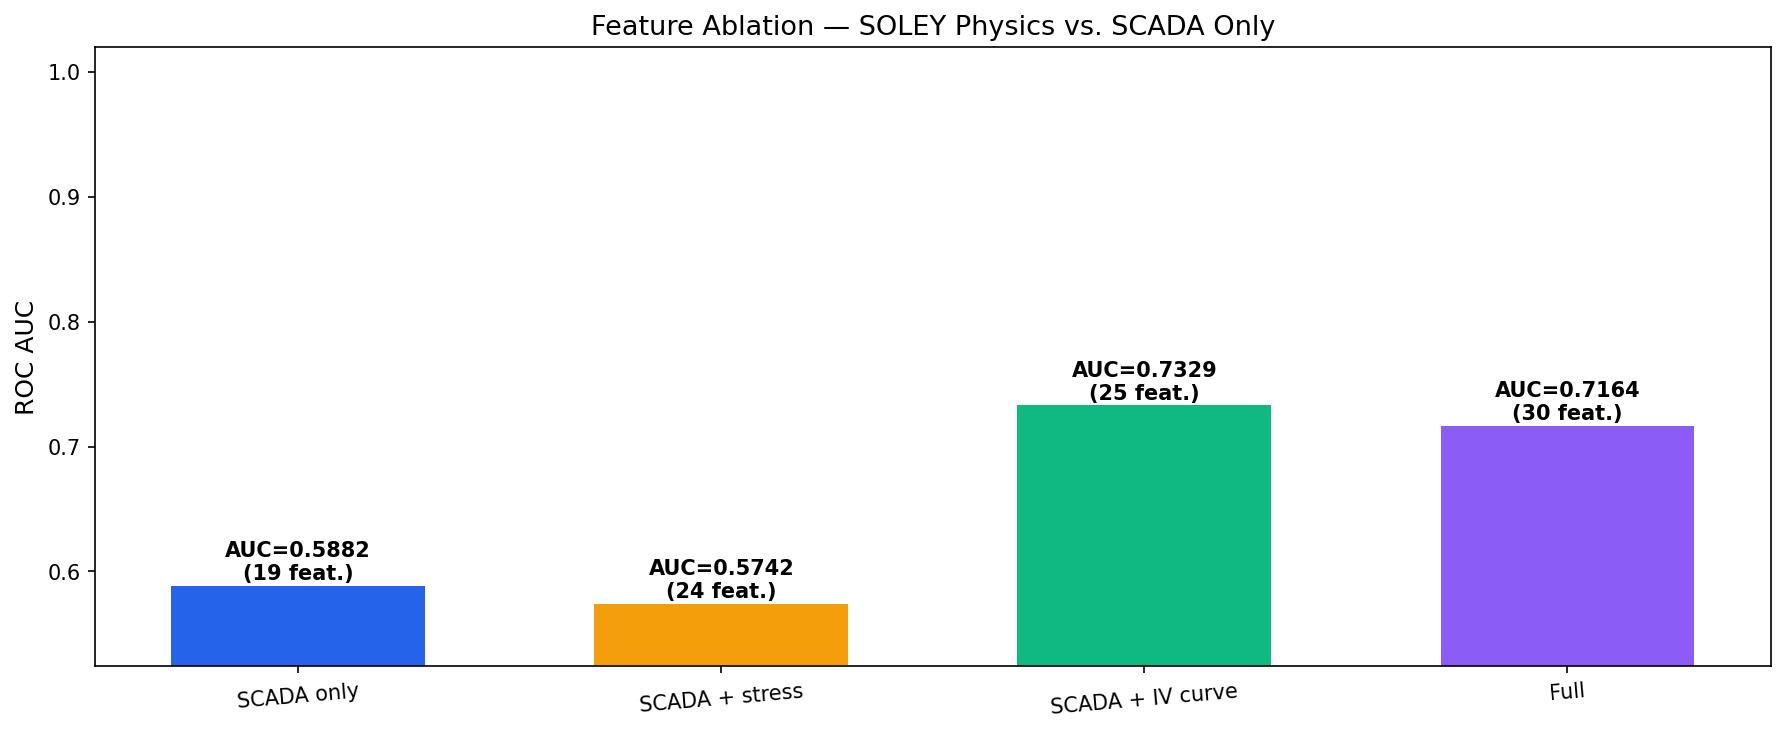

In [13]:
from library.evaluation import run_feature_ablation

ablation_results = run_feature_ablation(
    registry,
    pathlib.Path(OUTPUT_DIR),
    cfg,
    model_modes=MODEL_MODES,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    device=device,
    patience=PATIENCE,
    num_workers=n_workers,
    max_train_rows=MAX_TRAIN_ROWS,
    max_test_rows=MAX_TEST_ROWS,
    majority_thin_factor=MAJORITY_THIN_FACTOR,
    rows_per_batch=ROWS_PER_BATCH,
    files_per_batch=FILES_PER_BATCH,
    custom_runners=CUSTOM_MODEL_RUNNERS,
)
if ablation_results:
    display(pd.DataFrame(ablation_results))
    for mode in sorted({row["model_mode"] for row in ablation_results}):
        p = pathlib.Path(OUTPUT_DIR) / f"feature_ablation_{mode}.png"
        if p.exists():
            print(f"\nFeature ablation — {mode.upper()}")
            ipy_display(Image(str(p)))


## 11. Saved artifacts

In [14]:
# ── A1 + A2 fix: persist registry (with splits) + model artifact paths ──────
# Notebook 03 loads this manifest instead of re-running prepare_file_registry()
# + assign_splits(), eliminating the split-leakage risk and the hardcoded
# path reconstruction that caused RF models to never appear in eval.
#
# Bug 6 fix: also persist scaler and label-encoder paths so notebook 03's
# eval_pytorch_model() doesn't have to reconstruct them from hardcoded naming
# conventions that break when artifact_prefix is non-default.
model_paths = {
    "fault_active": {m: d.get("model_path") for m, d in detection_details.items()},
    "fault_type":   {m: d.get("model_path") for m, d in classification_details.items()},
}

import pathlib as _pl
scaler_paths = {
    "fault_active": str(_pl.Path(OUTPUT_DIR) / "scaler_fault_detection.pkl"),
    "fault_type":   str(_pl.Path(OUTPUT_DIR) / "scaler_fault_classification.pkl"),
}
le_paths = {
    "fault_type": str(_pl.Path(OUTPUT_DIR) / "label_encoder_fault_classification.pkl"),
}

save_registry_manifest(
    registry,
    MANIFEST_PATH,
    model_paths=model_paths,
    extra={
        "data_dir":     DATA_DIR,
        "max_runs":     MAX_RUNS,
        "majority_thin_factor": MAJORITY_THIN_FACTOR,
        "max_train_rows": MAX_TRAIN_ROWS,
        "max_test_rows": MAX_TEST_ROWS,
        "rows_per_batch": ROWS_PER_BATCH,
        "files_per_batch": FILES_PER_BATCH,
        "scaler_paths": scaler_paths,
        "le_paths":     le_paths,
    },
)
print(f"Registry manifest saved: {MANIFEST_PATH}")
print("  Model paths saved for nb03 to load:")
for task, paths in model_paths.items():
    for mode, p in paths.items():
        print(f"    [{task}] {mode}: {p}")
print("  Scaler paths:", scaler_paths)
print("  LE paths:", le_paths)


Saved registry manifest: outputs/sequence_models/registry_manifest.json  (418 files, 79 split-test)
Registry manifest saved: outputs/sequence_models/registry_manifest.json
  Model paths saved for nb03 to load:
    [fault_active] random_forest: outputs/sequence_models/model_fault_detection_random_forest.pkl
    [fault_active] mlp: outputs/sequence_models/model_fault_detection_mlp.pt
    [fault_active] lstm: outputs/sequence_models/model_fault_detection_lstm.pt
    [fault_active] hybrid: outputs/sequence_models/model_fault_detection_hybrid.pt
    [fault_type] random_forest: outputs/sequence_models/model_fault_classification_random_forest.pkl
    [fault_type] mlp: outputs/sequence_models/model_fault_classification_mlp.pt
    [fault_type] lstm: outputs/sequence_models/model_fault_classification_lstm.pt
    [fault_type] hybrid: outputs/sequence_models/model_fault_classification_hybrid.pt
  Scaler paths: {'fault_active': 'outputs/sequence_models/scaler_fault_detection.pkl', 'fault_type': 'ou

In [15]:
outputs = sorted(pathlib.Path(OUTPUT_DIR).iterdir())
for f in outputs:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name:<55s}  {size_mb:.2f} MB")


  confusion_ablation_full_hybrid.png                       0.04 MB
  confusion_ablation_full_lstm.png                         0.04 MB
  confusion_ablation_full_mlp.png                          0.04 MB
  confusion_ablation_full_random_forest.png                0.04 MB
  confusion_ablation_scada_only_hybrid.png                 0.04 MB
  confusion_ablation_scada_only_lstm.png                   0.04 MB
  confusion_ablation_scada_only_mlp.png                    0.04 MB
  confusion_ablation_scada_only_random_forest.png          0.04 MB
  confusion_ablation_scada_plus_iv_curve_hybrid.png        0.04 MB
  confusion_ablation_scada_plus_iv_curve_lstm.png          0.04 MB
  confusion_ablation_scada_plus_iv_curve_mlp.png           0.04 MB
  confusion_ablation_scada_plus_iv_curve_random_forest.png  0.04 MB
  confusion_ablation_scada_plus_stress_hybrid.png          0.04 MB
  confusion_ablation_scada_plus_stress_lstm.png            0.04 MB
  confusion_ablation_scada_plus_stress_mlp.png             0.